# Frozen Lake: Monte Carlo Methods

## Introduction

This notebook shows how to use simple MC methods to Gymnasium's Frozen lake environment, a small toy example for stochastic actions. 
Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake.

The frozen lake environment is defined in `gymnasium` (not `gym-classics`) and only provides sample access. Here is the [environment description.](https://gymnasium.farama.org/environments/toy_text/frozen_lake/)

The size of the problem, the randomness and the reward structure can be adjusted.

## Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [10]:
import numpy as np
np.set_printoptions(precision=2)

In [11]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


In [12]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py", 
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/common/")

## A Simple Example

### Create the Environment

**Note:** `success_rate` makes the ground slippery leading to stochastic behavior! From the [environment description](https://gymnasium.farama.org/environments/toy_text/frozen_lake/):

> `is_slippery=True`: If true the player will move in intended direction with probability specified by the 
> success_rate else will move in either perpendicular direction with equal probability in both directions.

I use here `success_rate=90.0/100.0` meaning that the ice is not very slippery and the agent will move with 90% probability into the direction of the chosen action. 

In [13]:
from gymnasium_display_recorder import VideoWrapper, show

env = gym.make('FrozenLake-v1', 
               map_name="4x4", # can also be "8x8"
               is_slippery=True,
               success_rate=90.0/100.0,
               reward_schedule=(1, 0, 0),
               render_mode="rgb_array")

env_record = VideoWrapper(env, 'FL', render_fps=2)

Videos already exist, I remove them first!


/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/mhahsler/github/Introduction_to_Reinforcement_Learning/MC/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


We need simple code to run an episode.

In [14]:
def run_episode(agent_function, env, max_steps=1000, verbose = True, render = True):
    """Run one episode in the environment using the provided agent."""

    # Reset the environment to generate the first observation (use seed=42 in reset to get reproducible results)
    observation, info = env.reset()

    Return = 0
    # run one episode
    for i in range(max_steps):
        # call the agent function to select an action
        action = agent_function(observation)

        # step: execute an action in the environment
        observation_p, reward, terminated, truncated, info = env.step(action)

        if verbose:
            print (f"Step {i+1}: Obs {observation} -> Action {action} - > Reward {reward}, Obs' {observation_p}")

        observation = observation_p
        Return += reward

        # render the environment
        if render:
            env.render()

        if terminated:
            break
  
    if verbose:
        print(f"Episode Return: {Return}")
    
    return reward

### Random Agent

Check with am agent that moves randomly.

In [15]:
def random_agent_function(observation): 
    """A random agent that selects actions uniformly at random. It ignores the observation."""
    return env.action_space.sample()

In [16]:
run_episode(random_agent_function, env_record, max_steps = 100, verbose = True)
show(env_record)

Step 1: Obs 0 -> Action 0 - > Reward 0, Obs' 0
Step 2: Obs 0 -> Action 3 - > Reward 0, Obs' 0
Step 3: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 4: Obs 4 -> Action 3 - > Reward 0, Obs' 0
Step 5: Obs 0 -> Action 0 - > Reward 0, Obs' 0
Step 6: Obs 0 -> Action 3 - > Reward 0, Obs' 0
Step 7: Obs 0 -> Action 3 - > Reward 0, Obs' 0
Step 8: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 9: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 10: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 11: Obs 9 -> Action 2 - > Reward 0, Obs' 10
Step 12: Obs 10 -> Action 1 - > Reward 0, Obs' 14
Step 13: Obs 14 -> Action 0 - > Reward 0, Obs' 13
Step 14: Obs 13 -> Action 1 - > Reward 0, Obs' 13
Step 15: Obs 13 -> Action 3 - > Reward 0, Obs' 9
Step 16: Obs 9 -> Action 0 - > Reward 0, Obs' 8
Step 17: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 18: Obs 9 -> Action 3 - > Reward 0, Obs' 5
Episode Return: 0


Showing: ./videos/video_FL-episode-0.mp4


## Use MC Control with Exploring Starts 

We use here the implementation in `gym-classics`.

### Learn A Policy

I use history so I can look at how fast the algorithm learns.

In [17]:
from gym_classics.algorithms.monte_carlo_methods import MC_control_ES, MC_prediction

policy, Q, history = MC_control_ES(env, discount=1, n = 25000, max_episode_len= 30, history = True)

MC Control (Incremental): 100%|██████████| 25000/25000 [00:21<00:00, 1165.29it/s]


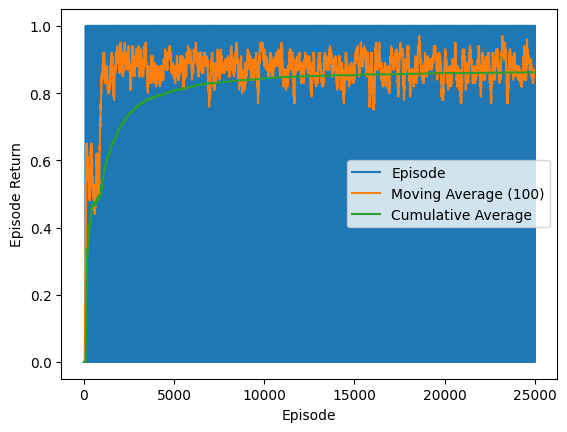

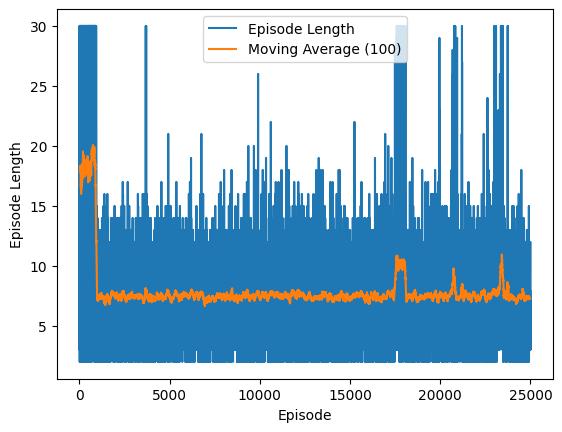

In [18]:
from gym_classics.performance import plot_returns, plot_ep_lens
plot_returns(history['returns'])
plot_ep_lens([len(x) for x in history['episodes']])

In [19]:
#from gym_classics.algorithms.monte_carlo_methods import MC_control_ES, MC_prediction
#pol, Q = MC_control_ES(env, discount=1, n = 25000, max_episode_len= 30)

# extract the final policy from history 
pol = pol_list[-1]
Q = Q_list[-1]

NameError: name 'pol_list' is not defined

Let's make the policy more readable and follow the layout of the problem.

In [ ]:
def decode_action(action):
    return ['←','↓','→','↑'][int(action)]

def decode_policy(policy):
    return np.array([decode_action(a) for a in policy])

In [ ]:
decode_policy(pol).reshape(4,4)

array([['↓', '←', '↓', '↓'],
       ['↓', '↓', '↓', '←'],
       ['→', '↓', '↓', '↓'],
       ['↑', '→', '→', '↓']], dtype='<U1')

Note that the agent sometimes runs into the wall to avoid the chance of falling into the lake.

MC Control returns the estimated Q-function. We can extract the value function to see the value for each state.

In [ ]:
V = np.max(Q, axis = 1)
V.reshape(4,4)

array([[0.88, 0.81, 0.86, 0.88],
       [0.88, 0.87, 0.89, 0.88],
       [0.93, 0.99, 0.94, 0.89],
       [0.85, 0.99, 0.99, 0.89]])

### Predict the Value Function

We can also use MC prediction (implemented in `gym-classics`). 

In [ ]:
V = MC_prediction(env, pol, discount = 1, n =1000)
V.reshape(4,4)

MC Prediction: 100%|██████████| 1000/1000 [00:00<00:00, 5947.19it/s]


array([[0.88, 0.91,  nan,  nan],
       [0.88,  nan,  nan,  nan],
       [0.93, 0.99, 0.93,  nan],
       [ nan, 1.  , 1.  ,  nan]])

Note that the samples always start from the start state and only follow the policy, so many states have no estimate. 

### Experiment with the Learned Policy

In [ ]:
def policy_agent_function_generator(policy):
    def agent_function(obs):
        return policy[obs]
    return agent_function

In [ ]:
policy_agent_function = policy_agent_function_generator(pol)

for i in range(10):
    G = run_episode(policy_agent_function, env_record, max_steps = 100)
    print(f"Episode {i}: Retrun={G}")
    show(env_record)


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 6: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 0: Retrun=1
Showing: ./videos/video_FL-episode-1.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 13
Step 6: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 7: Obs 14 -> Action 2 - > Reward 0, Obs' 10
Step 8: Obs 10 -> Action 1 - > Reward 0, Obs' 14
Step 9: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 1: Retrun=1
Showing: ./videos/video_FL-episode-2.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 6: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 2: Retrun=1
Showing: ./videos/video_FL-episode-3.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 6: Obs 14 -> Action 2 - > Reward 0, Obs' 10
Step 7: Obs 10 -> Action 1 - > Reward 0, Obs' 14
Step 8: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 3: Retrun=1
Showing: ./videos/video_FL-episode-4.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 0
Step 2: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 3: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 4: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 5: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 6: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 7: Obs 14 -> Action 2 - > Reward 0, Obs' 14
Step 8: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 4: Retrun=1
Showing: ./videos/video_FL-episode-5.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 9
Step 6: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 7: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 8: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 5: Retrun=1
Showing: ./videos/video_FL-episode-6.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 6: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 6: Retrun=1
Showing: ./videos/video_FL-episode-7.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 6: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 7: Retrun=1
Showing: ./videos/video_FL-episode-8.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 6: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 8: Retrun=1
Showing: ./videos/video_FL-episode-9.mp4


Step 1: Obs 0 -> Action 1 - > Reward 0, Obs' 4
Step 2: Obs 4 -> Action 1 - > Reward 0, Obs' 8
Step 3: Obs 8 -> Action 2 - > Reward 0, Obs' 9
Step 4: Obs 9 -> Action 1 - > Reward 0, Obs' 13
Step 5: Obs 13 -> Action 2 - > Reward 0, Obs' 14
Step 6: Obs 14 -> Action 2 - > Reward 1, Obs' 15
Episode Return: 1
Episode 9: Retrun=1
Showing: ./videos/video_FL-episode-10.mp4


Perform evaluation with 100 random runs.

In [ ]:
def policy_agent_function(obs):
    return pol[obs]

Gs = []

for i in range(100):
    G = run_episode(policy_agent_function, env, max_steps = 100, verbose = False)
    Gs.append(G)
   
print(Gs) 

print (f"Success rate: {np.mean(Gs)*100}%")

[1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Success rate: 92.0%


The success rate is rather high since we use a very small problem and a very high success rate.

## Reward Engineering

The Frozen Lake example lets us change the reward function. The default reward schedule:
* Reach goal: +1
* Reach hole: 0
* Reach frozen: 0 (walk on ice)


An important part of RL is to specify the reward so it is helpful for learning.  For the default setting, the agent initially no idea where to go and performs a random walk. 
All Q-values are initialized to 0 and do't change unless the agent randomly reaches the goa which may be very unlikely for large lakes. Lets change the reward structure
to make the agent scared of holes and a little more interested in walking on ice.

* Reach goal: +1 
* Reach hole: -.5
* Reach frozen: +0.01 (walk on ice)


In [ ]:
env2 = gym.make('FrozenLake-v1', 
               map_name="4x4", # can also be "8x8"
               is_slippery=True,
               success_rate=90.0/100.0,
               reward_schedule=(1, -.5, 0.001),
               render_mode="rgb_array")

env_record2 = VideoWrapper(env2, 'FL2', render_fps=2)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/mhahsler/github/Introduction_to_Reinforcement_Learning/MC/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
run_episode(random_agent_function, env2, max_steps=1000, verbose = True)

Step 1: Obs 0 -> Action 0 - > Reward 0.001, Obs' 0
Step 2: Obs 0 -> Action 0 - > Reward 0.001, Obs' 0
Step 3: Obs 0 -> Action 2 - > Reward 0.001, Obs' 1
Step 4: Obs 1 -> Action 2 - > Reward -0.5, Obs' 5
Episode Return: -0.497


-0.5

Let's run a single episode and see how Q updates.

In [ ]:
from gym_classics.algorithms.monte_carlo_methods import MC_control_ES, MC_prediction
pol2, Q2 = MC_control_ES(env2, discount=1, n = 1, max_episode_len= 30)
Q2

MC Control (Incremental): 100%|██████████| 1/1 [00:00<00:00, 807.06it/s]


array([[ 0. , -0.5,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. , -0.5,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. , -0.5,  0. ,  0. ],
       [ 0. , -0.5,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [-0.5,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ]])

Let's learn from more episodes

In [ ]:

pol2, Q2 = MC_control_ES(env2, discount=1, n = 10000, max_episode_len= 100)
pol2

MC Control (Incremental): 100%|██████████| 10000/10000 [00:18<00:00, 540.23it/s]


array([2, 3, 3, 3, 3, 0, 2, 3, 2, 0, 0, 3, 2, 3, 0, 2])

In [ ]:
decode_policy(pol2).reshape(4,4)

array([['→', '↑', '↑', '↑'],
       ['↑', '←', '→', '↑'],
       ['→', '←', '←', '↑'],
       ['→', '↑', '←', '→']], dtype='<U1')

In [ ]:
V = np.array([np.max(x) for x in Q2])
#V = MC_prediction(env, pol2, discount = 1, n =1000, verbose = False)
V.reshape(4,4)

array([[0.04, 0.01, 0.01, 0.01],
       [0.04, 0.08, 0.02, 0.08],
       [0.06, 0.07, 0.07, 0.09],
       [0.09, 0.09, 0.07, 0.09]])

This hopefully leads to better learning performance. But note, there is a chance for reward hacking! If we give the agent a large reward for walking around on the ice, then it will do that and avoid the goal to keep on getting reward.

Play with the reward function.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)